[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/brianjalaian/CAP6606_ML_ISR/blob/main/notebooks/02_neural_networks.ipynb)
[![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/brianjalaian/CAP6606_ML_ISR/blob/main/notebooks/02_neural_networks.ipynb)

# Neural Networks: Theory & Fundamentals

**From affine neurons to a complete NumPy backpropagation implementation**

This notebook follows the lecture notation exactly: a mini-batch $\mathbf{X}\in\mathbb{R}^{B\times D}$ passes through a hidden layer of width $H$ and produces $K$ class probabilities.

## Learning Objectives

By the end of this notebook, you will be able to:

1. Trace tensor shapes through an MLP forward pass
2. Explain why nonlinear hidden features solve problems that a linear model cannot
3. Implement stable softmax and cross-entropy
4. Derive and verify backpropagation with finite differences
5. Train a two-layer neural network using only NumPy
6. Diagnose the effects of learning rate and regularization from training curves

## 1. Setup and Locked Notation

We use:

- $B$: mini-batch size
- $D$: number of input features
- $H$: hidden width
- $K$: number of output classes
- $\mathbf{X}:(B,D)$, $\mathbf{W}^{(1)}:(D,H)$, $\mathbf{W}^{(2)}:(H,K)$

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=ConvergenceWarning)
np.set_printoptions(precision=4, suppress=True)
plt.style.use("seaborn-v0_8-whitegrid")
RANDOM_STATE = 42
print("Imports complete; random state =", RANDOM_STATE)

Matplotlib is building the font cache; this may take a moment.


Imports complete; random state = 42


In [2]:
def stable_softmax(logits):
    shifted = logits - logits.max(axis=1, keepdims=True)
    exp_scores = np.exp(shifted)
    return exp_scores / exp_scores.sum(axis=1, keepdims=True)

rng = np.random.default_rng(RANDOM_STATE)
B, D, H, K = 4, 3, 5, 2
X_demo = rng.normal(size=(B, D))
W1_demo = rng.normal(scale=np.sqrt(2 / D), size=(D, H))
b1_demo = np.zeros(H)
W2_demo = rng.normal(scale=np.sqrt(2 / H), size=(H, K))
b2_demo = np.zeros(K)

Z1_demo = X_demo @ W1_demo + b1_demo
A1_demo = np.maximum(0, Z1_demo)
Z2_demo = A1_demo @ W2_demo + b2_demo
P_demo = stable_softmax(Z2_demo)

for name, array in [("X", X_demo), ("Z1", Z1_demo), ("A1", A1_demo), ("Z2", Z2_demo), ("P", P_demo)]:
    print(f"{name:>2}: shape={array.shape}")
print("Probability row sums:", P_demo.sum(axis=1))

 X: shape=(4, 3)
Z1: shape=(4, 5)
A1: shape=(4, 5)
Z2: shape=(4, 2)
 P: shape=(4, 2)
Probability row sums: [1. 1. 1. 1.]


The inner dimensions of every matrix product must agree. Bias vectors broadcast across the batch dimension. Softmax preserves the $(B,K)$ shape and normalizes each row.

## 2. Activations Create Nonlinear Features

Stacking affine transformations without an activation still produces one affine transformation. An activation changes the function class by bending the representation between layers.

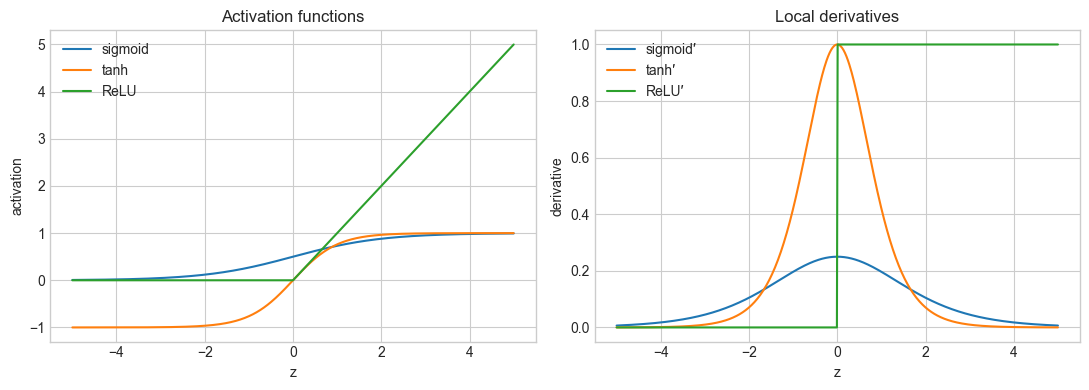

In [3]:
z = np.linspace(-5, 5, 600)
sigmoid = 1 / (1 + np.exp(-z))
tanh = np.tanh(z)
relu = np.maximum(0, z)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(z, sigmoid, label="sigmoid")
axes[0].plot(z, tanh, label="tanh")
axes[0].plot(z, relu, label="ReLU")
axes[0].set(title="Activation functions", xlabel="z", ylabel="activation")
axes[0].legend()

axes[1].plot(z, sigmoid * (1 - sigmoid), label="sigmoid′")
axes[1].plot(z, 1 - tanh**2, label="tanh′")
axes[1].plot(z, (z > 0).astype(float), label="ReLU′")
axes[1].set(title="Local derivatives", xlabel="z", ylabel="derivative", ylim=(-0.05, 1.05))
axes[1].legend()
plt.tight_layout()
plt.show()

### A concrete representation: XOR

For binary inputs, two ReLU hidden features solve XOR exactly:

$$h_1=\operatorname{ReLU}(x_1+x_2),\qquad h_2=\operatorname{ReLU}(x_1+x_2-1),$$
$$\hat y=h_1-2h_2.$$

The hidden layer changes the representation so that a linear output can solve the transformed problem.

In [4]:
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
h1 = np.maximum(0, X_xor.sum(axis=1))
h2 = np.maximum(0, X_xor.sum(axis=1) - 1)
y_xor = h1 - 2 * h2
print(np.c_[X_xor, h1, h2, y_xor])

[[0. 0. 0. 0. 0.]
 [0. 1. 1. 0. 1.]
 [1. 0. 1. 0. 1.]
 [1. 1. 2. 1. 0.]]


## 3. Empirical Checkpoint: Linear Model vs MLP

The two-moons dataset is deliberately nonlinear. Both models receive the same standardized features; only their representational capacity differs.

In [5]:
X, y = make_moons(n_samples=600, noise=0.22, random_state=RANDOM_STATE)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)

linear_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(C=10, max_iter=2000, random_state=RANDOM_STATE),
)
mlp_model = make_pipeline(
    StandardScaler(),
    MLPClassifier(
        hidden_layer_sizes=(16,), activation="relu", solver="adam",
        alpha=1e-4, learning_rate_init=0.01, max_iter=600,
        early_stopping=True, n_iter_no_change=35, random_state=RANDOM_STATE,
    ),
)

for model in (linear_model, mlp_model):
    model.fit(X_train, y_train)

print(f"Logistic regression test accuracy: {linear_model.score(X_test, y_test):.3f}")
print(f"MLP test accuracy:                 {mlp_model.score(X_test, y_test):.3f}")

Logistic regression test accuracy: 0.861
MLP test accuracy:                 0.894


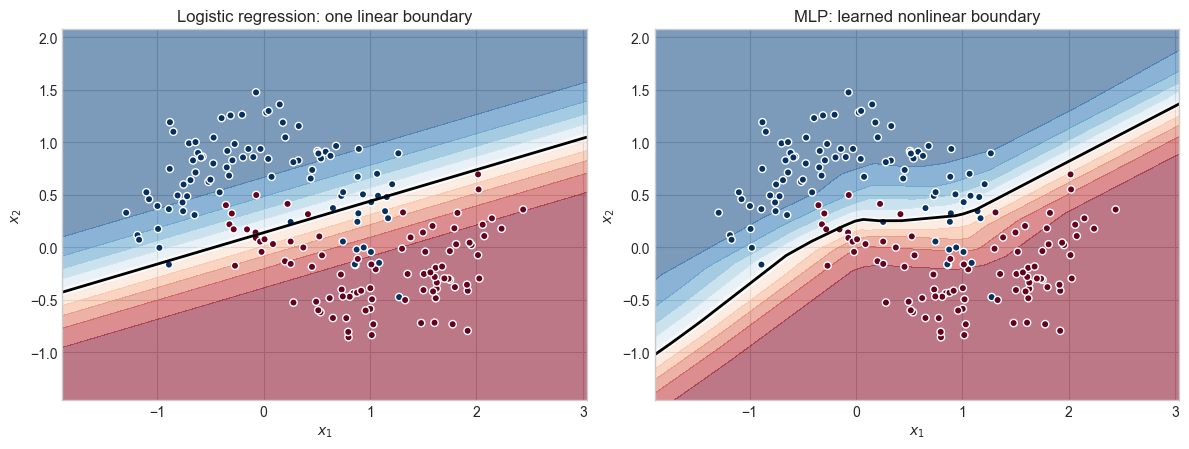

In [6]:
def plot_decision_boundary(ax, model, X, y, title):
    pad = 0.6
    x1 = np.linspace(X[:, 0].min() - pad, X[:, 0].max() + pad, 350)
    x2 = np.linspace(X[:, 1].min() - pad, X[:, 1].max() + pad, 350)
    xx1, xx2 = np.meshgrid(x1, x2)
    grid = np.c_[xx1.ravel(), xx2.ravel()]
    prob = model.predict_proba(grid)[:, 1].reshape(xx1.shape)
    ax.contourf(xx1, xx2, prob, levels=np.linspace(0, 1, 12), cmap="RdBu_r", alpha=0.55)
    ax.contour(xx1, xx2, prob, levels=[0.5], colors="black", linewidths=2)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="RdBu_r", edgecolor="white", s=28)
    ax.set(title=title, xlabel="$x_1$", ylabel="$x_2$")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
plot_decision_boundary(axes[0], linear_model, X_test, y_test, "Logistic regression: one linear boundary")
plot_decision_boundary(axes[1], mlp_model, X_test, y_test, "MLP: learned nonlinear boundary")
plt.tight_layout()
plt.show()

## 4. Stable Softmax and Cross-Entropy

For one-hot targets $\mathbf{Y}$, the averaged cross-entropy is

$$\mathcal{L}=-\frac{1}{B}\sum_{i=1}^{B}\sum_{k=1}^{K}y_{ik}\log(p_{ik}+\varepsilon).$$

Subtracting each row's maximum before exponentiation avoids overflow without changing softmax probabilities.

In [7]:
def cross_entropy(probabilities, y_true):
    return -np.log(probabilities[np.arange(len(y_true)), y_true] + 1e-12).mean()

extreme_logits = np.array([[1000.0, 1001.0, 999.0], [-1000.0, -999.0, -1002.0]])
probabilities = stable_softmax(extreme_logits)
print("Stable probabilities:\n", probabilities)
print("Row sums:", probabilities.sum(axis=1))
print("Cross-entropy:", cross_entropy(probabilities, np.array([1, 1])))

Stable probabilities:
 [[0.24472847 0.66524096 0.09003057]
 [0.25949646 0.70538451 0.03511903]]
Row sums: [1. 1.]
Cross-entropy: 0.378309090604823


## 5. Backpropagation in Matrix Form

For a ReLU hidden layer and softmax output:

$$\mathbf{G}^{(2)}=(\mathbf{P}-\mathbf{Y})/B,$$
$$\nabla_{\mathbf{W}^{(2)}}\mathcal{L}=\mathbf{A}^{(1)\top}\mathbf{G}^{(2)},$$
$$\mathbf{G}^{(1)}=(\mathbf{G}^{(2)}\mathbf{W}^{(2)\top})\odot\mathbf{1}[\mathbf{Z}^{(1)}>0],$$
$$\nabla_{\mathbf{W}^{(1)}}\mathcal{L}=\mathbf{X}^{\top}\mathbf{G}^{(1)}.$$

Bias gradients sum the corresponding $\mathbf{G}$ over the batch axis.

In [8]:
def forward(X, params):
    Z1 = X @ params["W1"] + params["b1"]
    A1 = np.maximum(0, Z1)
    Z2 = A1 @ params["W2"] + params["b2"]
    P = stable_softmax(Z2)
    return P, {"X": X, "Z1": Z1, "A1": A1, "P": P}

def backward(y, params, cache, l2=0.0):
    B = len(y)
    Y = np.eye(params["b2"].size)[y]
    G2 = (cache["P"] - Y) / B
    dW2 = cache["A1"].T @ G2 + l2 * params["W2"]
    db2 = G2.sum(axis=0)
    G1 = (G2 @ params["W2"].T) * (cache["Z1"] > 0)
    dW1 = cache["X"].T @ G1 + l2 * params["W1"]
    db1 = G1.sum(axis=0)
    return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2}

params_demo = {"W1": W1_demo.copy(), "b1": b1_demo.copy(), "W2": W2_demo.copy(), "b2": b2_demo.copy()}
y_demo = np.array([0, 1, 1, 0])
P, cache = forward(X_demo, params_demo)
grads = backward(y_demo, params_demo, cache)
for name in params_demo:
    print(f"{name}: parameter {params_demo[name].shape}, gradient {grads[name].shape}")

W1: parameter (3, 5), gradient (3, 5)
b1: parameter (5,), gradient (5,)
W2: parameter (5, 2), gradient (5, 2)
b2: parameter (2,), gradient (2,)


### Gradient checking

Backpropagation is easy to implement incorrectly. A centered finite difference provides an independent numerical check:

$$g_j^{num}=\frac{\mathcal{L}(\theta_j+\epsilon)-\mathcal{L}(\theta_j-\epsilon)}{2\epsilon}.$$

In [9]:
def gradient_check(X, y, params, epsilon=1e-5):
    P, cache = forward(X, params)
    analytic = backward(y, params, cache)
    numerical = {name: np.zeros_like(value) for name, value in params.items()}

    for name, value in params.items():
        for index in np.ndindex(value.shape):
            original = value[index]
            value[index] = original + epsilon
            plus = cross_entropy(forward(X, params)[0], y)
            value[index] = original - epsilon
            minus = cross_entropy(forward(X, params)[0], y)
            value[index] = original
            numerical[name][index] = (plus - minus) / (2 * epsilon)

    a = np.concatenate([analytic[name].ravel() for name in params])
    n = np.concatenate([numerical[name].ravel() for name in params])
    return np.linalg.norm(a - n) / (np.linalg.norm(a) + np.linalg.norm(n) + 1e-12)

tiny_rng = np.random.default_rng(7)
tiny_params = {
    "W1": tiny_rng.normal(0, 0.2, size=(3, 4)), "b1": np.full(4, 0.05),
    "W2": tiny_rng.normal(0, 0.2, size=(4, 2)), "b2": np.zeros(2),
}
relative_error = gradient_check(X_demo, y_demo, tiny_params)
print(f"Relative gradient error: {relative_error:.2e}")
assert relative_error < 1e-6

Relative gradient error: 4.59e-11


## 6. A Complete NumPy MLP

The implementation below adds He initialization, mini-batch updates, $L_2$ regularization, deterministic shuffling, and training-history capture. Frameworks automate these pieces, but the underlying operations are the same.

In [10]:
class NumPyMLP:
    def __init__(self, n_features, n_hidden, n_classes, learning_rate=0.05, l2=1e-4, random_state=42):
        self.learning_rate = learning_rate
        self.l2 = l2
        self.rng = np.random.default_rng(random_state)
        self.params = {
            "W1": self.rng.normal(0, np.sqrt(2 / n_features), size=(n_features, n_hidden)),
            "b1": np.zeros(n_hidden),
            "W2": self.rng.normal(0, np.sqrt(2 / n_hidden), size=(n_hidden, n_classes)),
            "b2": np.zeros(n_classes),
        }
        self.history = {"loss": [], "accuracy": []}

    def fit(self, X, y, epochs=800, batch_size=64):
        for _ in range(epochs):
            order = self.rng.permutation(len(X))
            for start in range(0, len(X), batch_size):
                idx = order[start:start + batch_size]
                P, cache = forward(X[idx], self.params)
                grads = backward(y[idx], self.params, cache, l2=self.l2)
                for name in self.params:
                    self.params[name] -= self.learning_rate * grads[name]

            P_all, _ = forward(X, self.params)
            data_loss = cross_entropy(P_all, y)
            penalty = 0.5 * self.l2 * (np.sum(self.params["W1"]**2) + np.sum(self.params["W2"]**2))
            self.history["loss"].append(data_loss + penalty)
            self.history["accuracy"].append(accuracy_score(y, P_all.argmax(axis=1)))
        return self

    def predict_proba(self, X):
        return forward(X, self.params)[0]

    def predict(self, X):
        return self.predict_proba(X).argmax(axis=1)

In [11]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

numpy_mlp = NumPyMLP(2, 16, 2, learning_rate=0.05, l2=1e-4, random_state=RANDOM_STATE)
numpy_mlp.fit(X_train_s, y_train, epochs=800, batch_size=64)

print(f"Final training accuracy: {numpy_mlp.history['accuracy'][-1]:.3f}")
print(f"Test accuracy:           {accuracy_score(y_test, numpy_mlp.predict(X_test_s)):.3f}")
print("Parameter count:", sum(value.size for value in numpy_mlp.params.values()))

Final training accuracy: 0.957
Test accuracy:           0.961
Parameter count: 82


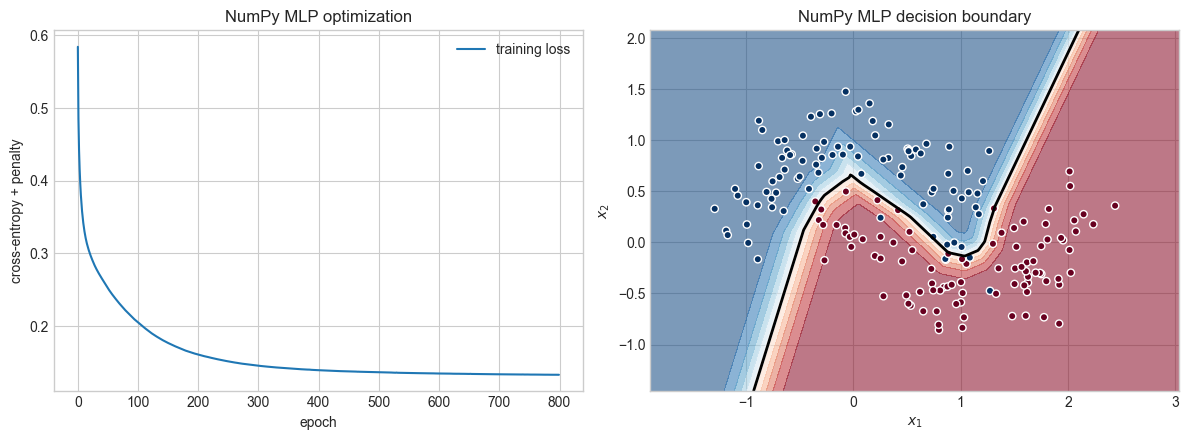

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(numpy_mlp.history["loss"], label="training loss")
axes[0].set(title="NumPy MLP optimization", xlabel="epoch", ylabel="cross-entropy + penalty")
axes[0].legend()

class ScaledNumPyMLP:
    def __init__(self, scaler, model):
        self.scaler, self.model = scaler, model
    def predict_proba(self, X):
        return self.model.predict_proba(self.scaler.transform(X))

plot_decision_boundary(axes[1], ScaledNumPyMLP(scaler, numpy_mlp), X_test, y_test, "NumPy MLP decision boundary")
plt.tight_layout()
plt.show()

## 7. Learning-Rate Experiment

Everything except the learning rate is held fixed. Compare both convergence speed and stability; the final loss alone does not tell the whole story.

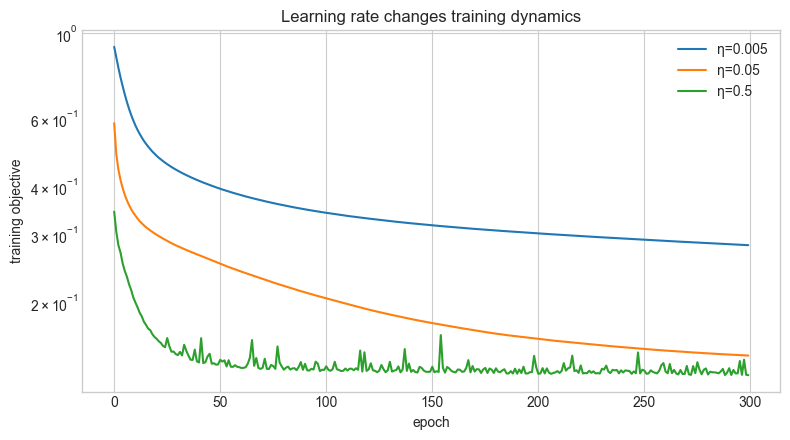

η=0.005 final loss=0.2816, test accuracy=0.889
η=0.05  final loss=0.1455, test accuracy=0.950
η=0.5   final loss=0.1294, test accuracy=0.961


In [13]:
rates = [0.005, 0.05, 0.5]
fig, ax = plt.subplots(figsize=(8, 4.5))
rate_results = []
for rate in rates:
    model = NumPyMLP(2, 16, 2, learning_rate=rate, l2=1e-4, random_state=RANDOM_STATE)
    model.fit(X_train_s, y_train, epochs=300, batch_size=64)
    test_acc = accuracy_score(y_test, model.predict(X_test_s))
    rate_results.append((rate, model.history["loss"][-1], test_acc))
    ax.plot(model.history["loss"], label=f"η={rate:g}")

ax.set(title="Learning rate changes training dynamics", xlabel="epoch", ylabel="training objective")
ax.set_yscale("log")
ax.legend()
plt.tight_layout()
plt.show()

for rate, loss, acc in rate_results:
    print(f"η={rate:<5g} final loss={loss:.4f}, test accuracy={acc:.3f}")

## 8. Validation Curves and Early Stopping

The scikit-learn MLP reserved part of the training data for validation. Early stopping keeps training from continuing after validation performance stops improving.

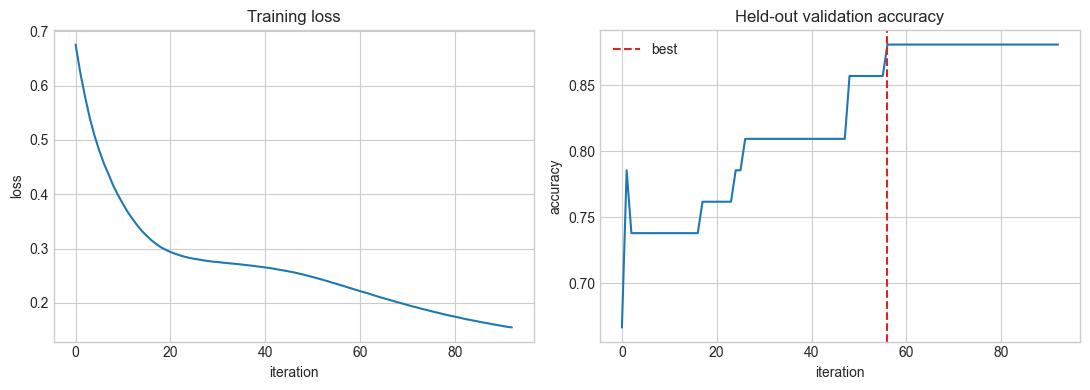

Stopped after 93 iterations; best validation score = 0.881


In [14]:
trained_mlp = mlp_model.named_steps["mlpclassifier"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(trained_mlp.loss_curve_)
axes[0].set(title="Training loss", xlabel="iteration", ylabel="loss")
if hasattr(trained_mlp, "validation_scores_") and trained_mlp.validation_scores_ is not None:
    axes[1].plot(trained_mlp.validation_scores_)
    axes[1].axvline(np.argmax(trained_mlp.validation_scores_), color="tab:red", linestyle="--", label="best")
    axes[1].legend()
axes[1].set(title="Held-out validation accuracy", xlabel="iteration", ylabel="accuracy")
plt.tight_layout()
plt.show()
print(f"Stopped after {trained_mlp.n_iter_} iterations; best validation score = {trained_mlp.best_validation_score_:.3f}")

## 9. Summary

- A hidden activation prevents stacked affine layers from collapsing into one linear model.
- Stable softmax and cross-entropy turn logits into a well-behaved multiclass objective.
- Backpropagation is the chain rule applied efficiently in reverse.
- Gradient checking validates the implementation before expensive training.
- He initialization, standardized inputs, learning rate, and regularization all affect trainability.
- Curves and error patterns are evidence; defaults are only starting points.

## Exercises

1. Replace ReLU with tanh in `NumPyMLP`; update both the forward and backward functions.
2. Add momentum to the optimizer and compare convergence at the three learning rates.
3. Sweep hidden width over $H\in\{2,4,16,64\}$ and plot train/test accuracy.
4. Make the two-moons noise level larger. Which intervention helps: width, regularization, or more data?

## References

- Rumelhart, D. E., Hinton, G. E., & Williams, R. J. (1986). *Learning representations by back-propagating errors*. Nature, 323, 533–536. https://www.nature.com/articles/323533a0
- Glorot, X., & Bengio, Y. (2010). *Understanding the difficulty of training deep feedforward neural networks*. AISTATS. https://proceedings.mlr.press/v9/glorot10a.html
- He, K., Zhang, X., Ren, S., & Sun, J. (2015). *Delving Deep into Rectifiers*. ICCV. https://openaccess.thecvf.com/content_iccv_2015/html/He_Delving_Deep_into_ICCV_2015_paper.html
- Raschka, S., & Mirjalili, V. (2022). *Machine Learning with PyTorch and Scikit-Learn*, Chapters 11–12.
- Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*, Chapters 6–8. https://www.deeplearningbook.org/